对于有无限个状态动作对的情况，我们需要用函数拟合的方法来估计Q值，即将这个复杂的Q值表格视作数据，使用一个参数化的函数$Q_{θ}$来拟合这些数据。很显然，这种函数拟合的方法存在一定的精度损失，因此被称为近似方法

CartPole 环境，它的状态值就是连续的，动作值是离散的（看成一个车上加着一个倒立摆），我们需要控制车的移动来使倒立摆平衡

在车杆环境中，有一辆小车，智能体的任务是通过左右移动保持车上的杆竖直，若杆的倾斜度数过大，或者车子离初始位置左右的偏离程度过大，或者坚持时间到达 200 帧，则游戏结束。智能体的状态是一个维数为 4 的向量，每一维都是连续的，其动作是离散的，动作空间大小为 2，在游戏中每坚持一帧，智能体能获得分数为 1 的奖励，坚持时间越长，则最后的分数越高，坚持 200 帧即可获得最高的分数

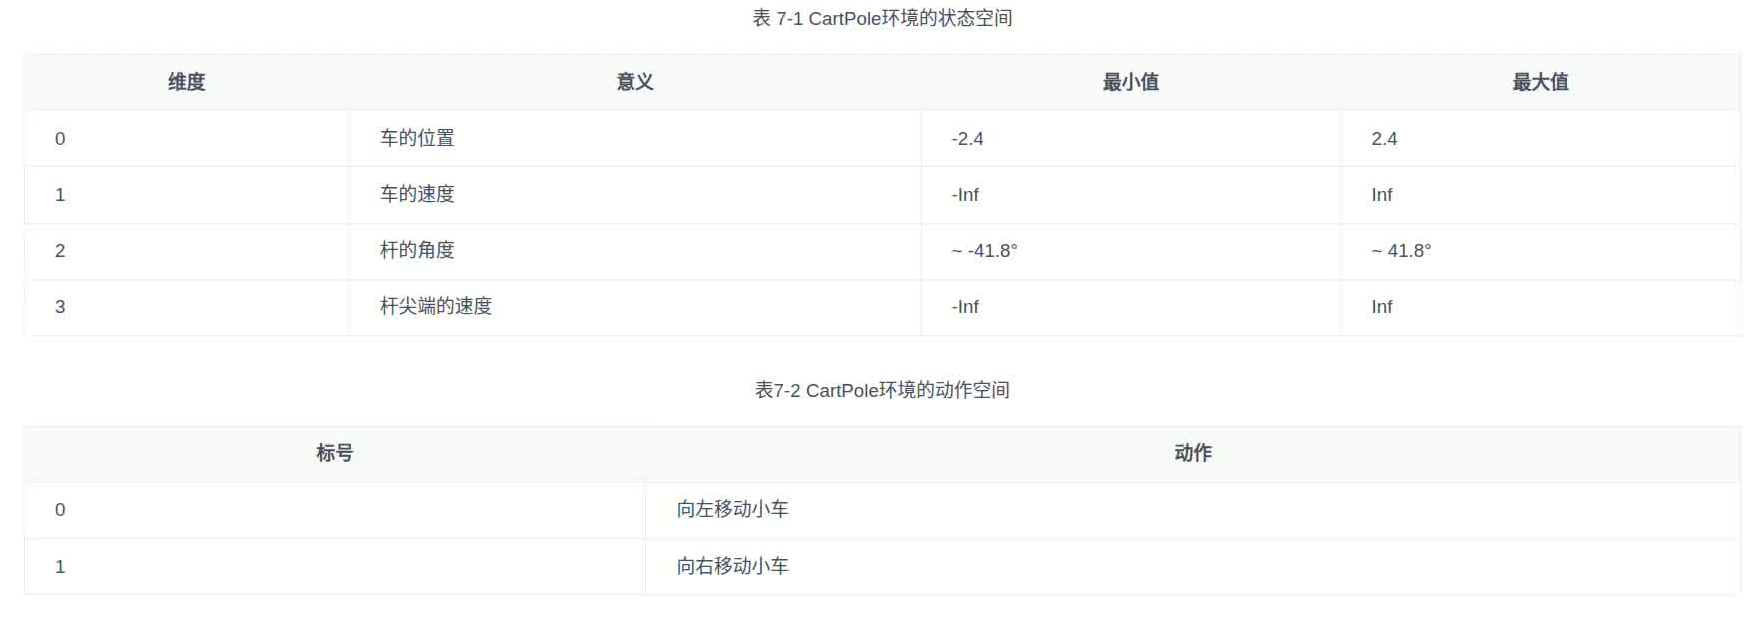

现在我们想在类似车杆的环境中得到动作价值函数Q(s,a)，由于状态每一维度的值都是连续的，无法使用表格记录，因此一个常见的解决方法便是使用函数拟合的思想，由于神经网络具有强大的表达能力，因此我们可以用一个神经网络来表示函数Q，若动作是连续（无限）的，神经网络的输入是状态s和动作a，然后输出一个标量，表示在状态下采取动作能获得的价值。若动作是离散（有限）的，除了可以采取动作连续情况下的做法，我们还可以只将状态输入到神经网络中，使其同时输出每一个动作的Q值，通常 DQN（以及 Q-learning）只能处理动作离散的情况，因为在函数Q的更新过程中有$max_a$这一操作，假设神经网络用来拟合函数的参数是$w$，即每一个状态下所有可能动作的Q值都能表示为$Q_w(s,a)$；我们将用于拟合函数Q函数的神经网络称为Q网络

采用的测试环境是 CartPole-v0，其状态空间相对简单，只有 4 个变量，因此网络结构的设计也相对简单：采用一层 128 个神经元的全连接并以 ReLU 作为激活函数。当遇到更复杂的诸如以图像作为输入的环境时，我们可以考虑采用深度卷积神经网络。

In [1]:
import random
import gym
import numpy as np
import collections
from tqdm import tqdm
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import rl_utils
import time
from IPython import display

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


定义经验回放池的类，主要包括加入数据、采样数据两大函数。

In [3]:
class ReplayBuffer:
    """
        经验回放池
    """
    def __init__(self, capacity):
        """ 
            经验回放池初始化
            capacity：经验回放池最大存放数量；当达到上限的时候，最新数据会把最旧数据覆盖掉
        """
        # 创建一个大小capacity为队列,先进先出
        self.buffer = collections.deque(maxlen=capacity)  

    def add(self, state, action, reward, next_state, done):
        """
            将数据加入经验回放池
            state：当前状态
            action：当前状态执行的动作
            reward：执行动作后到达某一状态所获得的奖励
            next_state：下一状态
            done：是否终止
        """
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):  
        """
            从buffer中采样数据,数量为batch_size
            batch_size：每次随机采样的数量
        """
        # 从 buffer 中无放回地随机抽取 batch_size 个记忆元组，存放到列表 transitions 中
        transitions = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, done = zip(*transitions)
        
        return np.array(state), action, reward, np.array(next_state), done
    
    def size(self):  
        """
            目前buffer中数据的数量
        """
        return len(self.buffer)


定义一个只有一层隐藏层的 Q 网络

In [ ]:
class Qnet(torch.nn.Module):
    """
        只有一层隐藏层的Q网络
        torch.nn.Module：所有我们自己写的神经网络都必须继承它；
    """
    def __init__(self, state_dim, hidden_dim, action_dim):
        """
            Q网络初始化
            state_dim：输入层维度
            hidden_dim：隐藏层维度
            action_dim：输出层维度
        """
        # 调用父类的初始化方法
        super(Qnet, self).__init__()

        # 定义第一层全连接层
        self.fc1 = torch.nn.Linear(state_dim, hidden_dim)

        # 定义第二层全连接层
        self.fc2 = torch.nn.Linear(hidden_dim, action_dim)

    def forward(self, x):
        """
            前向传播，这里使用relu激活函数
            x：输入层特征
        """
        # 隐藏层使用ReLU激活函数
        x = F.relu(self.fc1(x))
        
        return self.fc2(x)

开始实现 DQN 算法

In [5]:
class DQN:
    """
        DQN算法
    """
    def __init__(self, state_dim, hidden_dim, action_dim, learning_rate, gamma,
                 epsilon, target_update, device):
        """
            DQN算法初始化
            state_dim：输入层维度
            hidden_dim：隐藏层维度
            action_dim：输出层维度
            learning_rate：学习率
            gamma：折扣因子
            epsilon：控制探索与利用的比例
            target_update：目标网络更新的频率
            device：指定运算设备
        """
        # 输出维度
        self.action_dim = action_dim
        # Q网络
        self.q_net = Qnet(state_dim, hidden_dim, self.action_dim).to(device)  
        # 目标网络
        self.target_q_net = Qnet(state_dim, hidden_dim, self.action_dim).to(device)
        # 使用Adam优化器，这里传的为 Q 网络，说明优化器只会更新当前 Q 网络的参数
        self.optimizer = torch.optim.Adam(self.q_net.parameters(), lr=learning_rate)
        # 折扣因子
        self.gamma = gamma  
        # epsilon-贪婪策略
        self.epsilon = epsilon  
        # 目标网络更新频率
        self.target_update = target_update  
        # 计数器,记录更新次数
        self.count = 0  
        # 挂载设备
        self.device = device

    def take_action(self, state):
        """
            epsilon-贪婪策略采取动作
            state：
        """
        if np.random.random() < self.epsilon:
            action = np.random.randint(self.action_dim)
        else:
            # 将 Numpy 的 state 转换成 tensor
            state = torch.tensor([state], dtype=torch.float).to(self.device)
            # 利用 Q 网络找到最大的 Q 值的动作
            action = self.q_net(state).argmax().item()
        
        return action
    
    def update(self, transition_dict):
        """
            策略更新
            transition_dict：从经验回放池取出的一个批次（Batch）的数据字典
        """
        # 将字典中各个
        states = torch.tensor(transition_dict['states'], dtype=torch.float).to(self.device)
        # view(-1, 1)变成一个 64 行 1 列的二维列向量，为了我们后面做矩阵加减法时，维度能够严格对齐
        actions = torch.tensor(transition_dict['actions']).view(-1, 1).to(self.device)
        rewards = torch.tensor(transition_dict['rewards'], dtype=torch.float).view(-1, 1).to(self.device)
        next_states = torch.tensor(transition_dict['next_states'], dtype=torch.float).to(self.device)
        dones = torch.tensor(transition_dict['dones'], dtype=torch.float).view(-1, 1).to(self.device)

        # 计算当前的 Q 值（主网络），计算我们当前挑选的批次下的状态的 Q 值，但是我们只选我们在当前状态执行动作的那个 Q 值；因为这里输出是（states，4）
        q_values = self.q_net(states).gather(1, actions) 

        # 计算目标的 Q 值（目标网络）
        max_next_q_values = self.target_q_net(next_states).max(1)[0].view(-1, 1)            # 先找到下一状态的最大的 Q 值
        q_targets = rewards + self.gamma * max_next_q_values * (1 - dones)                  # 计算当前状态下的目标 Q 值

        # 均方误差损失函数
        dqn_loss = torch.mean(F.mse_loss(q_values, q_targets))

        # PyTorch中默认梯度会累积,这里需要显式将梯度置为0
        self.optimizer.zero_grad()

        # 反向传播更新参数  
        dqn_loss.backward()             # 计算梯度
        self.optimizer.step()           # 调用优化器更新参数

        # 网络同步(更新目标网络)
        if self.count % self.target_update == 0:
            # 更新目标网络
            self.target_q_net.load_state_dict(      # 把这些参数直接强行覆盖到目标网络（老网络）里
                self.q_net.state_dict())            # 把主网络最近学习到的所有参数原封不动地提取出来
            
        # 计数器就加1
        self.count += 1

开始训练

In [6]:
# 超参数与硬件设置
lr = 2e-3             # 学习率 (Learning Rate)：神经网络每次更新参数的幅度。
num_episodes = 500    # 总回合数：打算让智能体玩多少局游戏。
hidden_dim = 128      # 隐藏层维度：Q网络的中间层有128个神经元。
gamma = 0.98          # 折扣因子：0.98 表示智能体非常看重长远利益。
epsilon = 0.01        # 探索率：1%的概率随机乱走，99%的概率听从Q网络（利用）。
target_update = 10    # 目标网络同步频率：主网络每更新10次，就把参数复制给目标网络。
buffer_size = 10000   # 回放池容量：最多记住 10000 步的经验。
minimal_size = 500    # 最小启动经验量：回放池里至少得有 500 条数据，才开始训练神经网络（防止一开始数据太少导致模型“死记硬背”）。
batch_size = 64       # 批次大小：每次从回放池里抓 64 条经验来训练。

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")      # 设备选择：如果有英伟达显卡（CUDA）就用GPU加速，否则用CPU。

# 环境初始化与随机种子
env_name = 'CartPole-v1'            # 设定游戏环境名称，这里是经典的“倒立摆”（推车保持杆子不倒）。
env = gym.make(env_name)            # 调用 OpenAI Gym 库，正式创建并初始化这个游戏环境。

# 下面连续 4 行都是在设置“随机种子”（Seed）
random.seed(0)                      # 固定 Python 原生库的随机种子
np.random.seed(0)                   # 固定 NumPy 的随机种子
env.seed(0)                         # 固定 Gym 环境内部的随机种子
torch.manual_seed(0)                # 固定 PyTorch 神经网络初始化的随机种子
# 每次随机初始化的网络权重和环境状态都一模一样，方便我们调试代码、对比不同算法的效果

# 核心组件实例化
replay_buffer = ReplayBuffer(buffer_size)               # 实例化我们之前写的经验回放池，容量一万。
state_dim = env.observation_space.shape[0]              # 获取环境状态的维度。CartPole 状态包含小车位置、速度、杆子角度等，所以维度是 4。
action_dim = env.action_space.n                         # 获取智能体能做的动作数量。CartPole 只能向左或向右推，所以动作维度是 2。
agent = DQN(state_dim, hidden_dim, action_dim, lr, gamma, epsilon, target_update, device) 
# 把前面的所有参数喂进去，正式诞生我们的 DQN 智能体（包含了大脑、目标网络和优化器）

# 外层循环（按回合进行）
return_list = [] # 创建一个空列表，用来记录每一局游戏智能体拿到的总分数，后续用来画折线图。

for i in range(10): 
    # 把 500 局游戏分成 10 个大块（每块 50 局），主要为了方便打印进度条。
    with tqdm(total=int(num_episodes / 10), desc='Iteration %d' % i) as pbar: 
        # 使用 tqdm 库创建一个极具高级感的终端进度条。
        
        for i_episode in range(int(num_episodes / 10)): 
            # 进入内层循环：开始跑当前的 50 局游戏中的每一局 (Episode)。
            episode_return = 0      # 每一局游戏开始前，先把当前这局的得分计数器清零。
            state = env.reset()     # 【极其重要】重置环境，生成这一局游戏的初始状态（小车回到中间，杆子随机倾斜一点点）。
            done = False            # 设定一个标志位，代表当前游戏还没结束 (Game Over)。

            # 内层循环（智能体与环境的实时交互与学习）
            while not done: # 只要游戏没结束（杆子没倒且没出界），就一直循环执行以下动作：
                # 1. 决策：智能体根据当前状态 `state`，使用 epsilon-贪心策略决定采取什么动作
                action = agent.take_action(state) 
                
                # 2. 执行：把决定的动作输入给环境。环境会返回：下一个状态、这步的奖励、游戏是否结束、以及调试信息（我们用 _ 忽略它）。
                next_state, reward, done, _ = env.step(action) 
                
                # 3. 记忆：把刚才发生的一切（状态、动作、奖励、下个状态、是否结束）打包成一条经验，扔进回放池。
                replay_buffer.add(state, action, reward, next_state, done) 
                
                # 4. 【新手极易漏掉的一步】：状态更新。把“下一个状态”变成“当前状态”，为了让 while 循环能继续往下走。
                state = next_state 
                
                # 5. 记分：把这一步拿到的奖励加到这局游戏的总分里。
                episode_return += reward 
                
                # --- 下面开始进入“边玩边学”阶段 ---
                # 6. 判断：如果池子里的经验数量大于 500 条了，说明积攒的数据够多了，可以开始训练大脑了。
                if replay_buffer.size() > minimal_size: 
                    # 7. 抽样：从池子里随机抽出 64 条经验数据。
                    b_s, b_a, b_r, b_ns, b_d = replay_buffer.sample(batch_size) 
                    
                    # 8. 组装：把抽出来的这堆数据打包成一个字典，键名对应上一问 `update` 函数里需要的名字。
                    transition_dict = {
                        'states': b_s,
                        'actions': b_a,
                        'next_states': b_ns,
                        'rewards': b_r,
                        'dones': b_d
                    } 
                    
                    # 9. 学习：调用 DQN 的核心更新函数，算 Loss、反向传播、更新神经网络参数、同步目标网络。全都在这一句里完成了！
                    agent.update(transition_dict) 
                    
            # 进度记录与终端显示
            # 把刚才这一局辛苦打出的总分，存到那个大列表里。
            return_list.append(episode_return) 
                
            # 每跑完 10 局游戏，就更新一次进度条的后缀信息。
            if (i_episode + 1) % 10 == 0: 
                
                pbar.set_postfix({
                    # 显示当前是第几局（比如当前是第 340 局）。
                    'episode': '%d' % (num_episodes / 10 * i + i_episode + 1), 
                    
                    'return': '%.3f' % np.mean(return_list[-10:]) 
                    # 【核心技巧】算一下最近 10 局分数的平均值。
                    # 因为单局游戏的随机性很大（这局可能拿 10 分，下局突然爆发拿 100 分），
                    # 看最近 10 局的“移动平均分”，能更稳定地看出智能体到底有没有在进步。
                })
            
            # 让进度条往前走一格。
            pbar.update(1) 

/home/kk/anaconda3/envs/rl_learn/lib/python3.8/site-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/home/kk/anaconda3/envs/rl_learn/lib/python3.8/site-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/home/kk/anaconda3/envs/rl_learn/lib/python3.8/site-packages/gym/core.py:256: DeprecationWarning: WARN: Function `env.seed(seed)` is marked as deprecated and will be removed in the future. Please use `env.reset(seed=seed)` instead.
  deprecation(
Iteration 0:   0%|          | 0/50 [00:00<?, ?it/s]/tmp/ipykernel_43371/237761633.py:46: UserWarning: Creatin

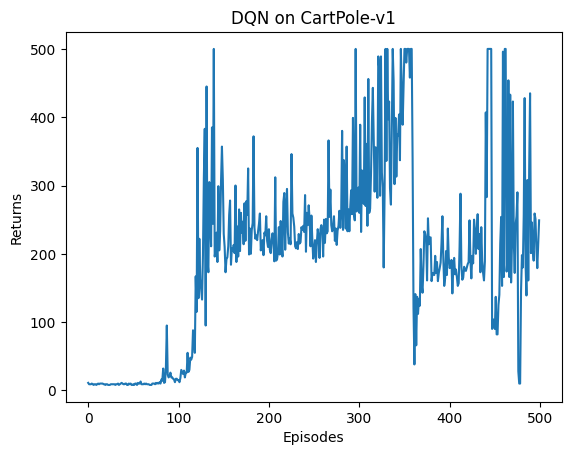

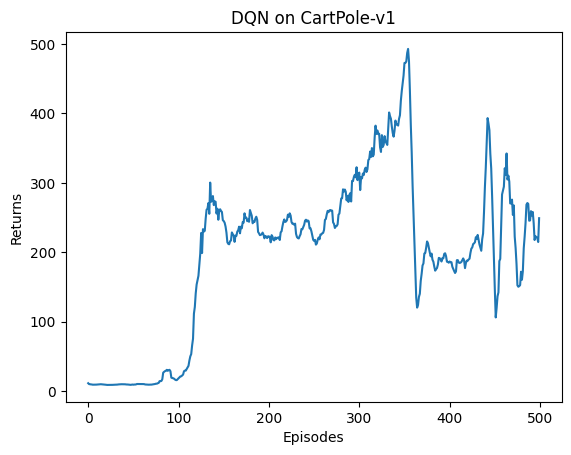

In [7]:
episodes_list = list(range(len(return_list)))
plt.plot(episodes_list, return_list)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('DQN on {}'.format(env_name))
plt.show()

mv_return = rl_utils.moving_average(return_list, 9)
plt.plot(episodes_list, mv_return)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('DQN on {}'.format(env_name))
plt.show()

可视化

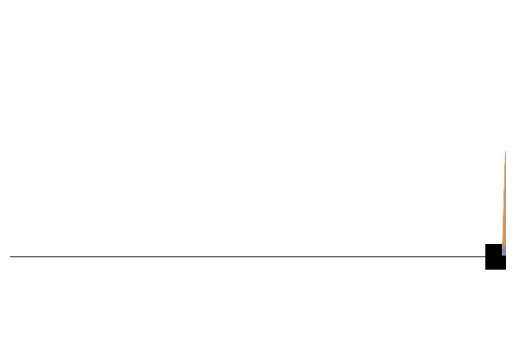

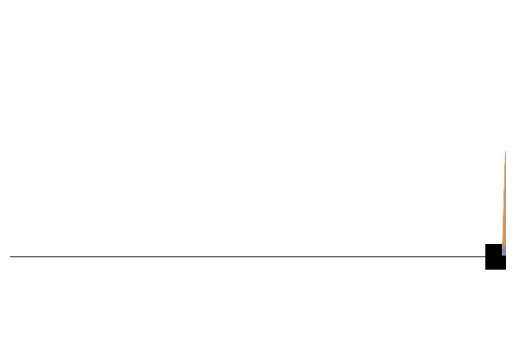

In [8]:
# 1. 设置为测试模式：关闭随机探索
agent.epsilon = 0.0 

# 2. 初始化环境
state = env.reset()
img = plt.imshow(env.render(mode='rgb_array')) # 抓取初始画面
plt.axis('off')

for _ in range(500): # 最多运行 500 步
    # 智能体决策
    action = agent.take_action(state)
    state, reward, done, _ = env.step(action)
    
    # 更新画面
    display.clear_output(wait=True)
    img.set_data(env.render(mode='rgb_array'))
    display.display(plt.gcf())
    
    if done:
        break
    time.sleep(0.02) # 控制播放速度

以图像为输入的 DQN 算法，使用非图像的状态作为输入（例如车杆环境中车的坐标、速度），但是在一些视频游戏中，智能体并不能直接获取这些状态信息，而只能直接获取屏幕中的图像。要让智能体和人一样玩游戏，我们需要让智能体学会以图像作为状态时的决策。将卷积层加入其网络结构以提取图像特征，最终实现以图像为输入的强化学习。以图像为输入的 DQN 算法的代码与上面不同之处主要在于 Q 网络的结构和数据输入。DQN 网络通常会将最近的几帧图像一起作为输入，从而感知环境的动态性。接下来我们实现以图像为输入的 DQN 算法，但由于代码需要运行较长的时间，我们在此便不展示训练结果。

In [9]:
class ConvolutionalQnet(torch.nn.Module):
    """
        加入卷积层的Q网络
    """
    def __init__(self, action_dim, in_channels=4):
        """
            初始化
            action_dim：输出层维度
            in_channels=4：通过将连续的 4 帧图像 叠在一起作为输入，神经网络就能通过对比帧与帧之间的差异，感知到物体的移动方向和快慢
            第一层卷积层激活函数
        """
        super(ConvolutionalQnet, self).__init__()

        # 第一层卷积：输入通道数为in_channels（通常是连续4帧画面），输出32个特征图
        # 卷积核大小为8x8，步长(stride)为4，用于提取大尺寸的图像特征并大幅压缩空间维度
        self.conv1 = torch.nn.Conv2d(in_channels, 32, kernel_size=8, stride=4)

        # 第二层卷积：输入32层，输出64层，卷积核4x4，步长为2
        # 进一步提取更深层的视觉特征，缩小特征图尺寸
        self.conv2 = torch.nn.Conv2d(32, 64, kernel_size=4, stride=2)

        # 第三层卷积：输入64层，输出64层，卷积核3x3，步长为1
        # 提取高层语义特征（如物体细微的位置变化），此时特征图已经变得非常小
        self.conv3 = torch.nn.Conv2d(64, 64, kernel_size=3, stride=1)

        # 第四层为全连接层：将卷积层输出的 7*7*64 个神经元映射到 512 个神经元的隐藏层
        # 这里 7*7 是经过上述三次卷积后图像剩下的空间分辨率
        self.fc4 = torch.nn.Linear(7 * 7 * 64, 512)

        # 输出层（Head）：将 512 维的隐藏特征映射到动作空间 action_dim
        # 输出的每个数值代表对应动作的 Q 值（即在该状态下采取该动作的预期收益）
        self.head = torch.nn.Linear(512, action_dim)

    def forward(self, x):
        """
            前向传播部分
            x：
            每一层卷积都使用 ReLU 激活函数
        """
        # 归一化，图像像素值通常在 0-255 之间。将其除以 255 缩放到 $[0, 1]$ 区间，可以使神经网络训练更加稳定且收敛更快
        x = x / 255
        
        # 第一层卷积层激活函数
        x = F.relu(self.conv1(x))
        
        # 第二层卷积层激活函数
        x = F.relu(self.conv2(x))
        
        # 第三层卷积层激活函数
        x = F.relu(self.conv3(x))

        # 展平处理（Flatten）：将多维的特征图（Batch, 64, 7, 7）拉直成一维向量（Batch, 3136）
        # 注意：图片原文中 forward 略过了这一步，但在代码实现中必须有 view 才能进入全连接层
        x = x.view(x.size(0), -1)

        # 经过 512 维的全连接层，并进行 ReLU 激活
        x = F.relu(self.fc4(x))

        # 最后通过输出层得到每个动作的 Q 值并返回
        return self.head(x)